# Agentic Receipt Audit — Kaggle Notebook (fixed)

This notebook is a cleaned, linear version..

Pipeline:
1. Install dependencies
2. Load and normalize **CORD v2**
3. Fine-tune **Qwen3-VL-2B-Instruct** with **LoRA**
4. Reload the adapter on a fresh base model
5. Parse JSON robustly
6. Evaluate and run an audit-style agent layer

In [1]:
# 1) Install dependencies

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["ACCELERATE_MIXED_PRECISION"] = "no"

!pip -q install -U git+https://github.com/huggingface/transformers
!pip -q install -U "gym>=0.26" "pillow<12.0.0" datasets accelerate peft trl bitsandbytes scikit-learn


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 11.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 78.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 9.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 105.1 MB/s eta 0:00:0000:0100:01


In [2]:
# 2) Imports and config

import os
import re
import gc
import json
import random
import warnings
from collections import Counter
from typing import Any, Dict, List, Optional, Tuple

import torch
import bitsandbytes as bnb
from PIL import Image

from datasets import load_dataset, Dataset
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen3VLForConditionalGeneration,
    set_seed,
)
from trl import SFTConfig, SFTTrainer

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)
random.seed(SEED)

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
DATASET_ID = "naver-clova-ix/cord-v2"

MAX_TRAIN_SAMPLES = 128
MAX_VALID_SAMPLES = 16
MAX_TEST_SAMPLES = 16

OUTPUT_DIR = "/kaggle/working/qwen3vl_cord_receipt_json"
ADAPTER_DIR = os.path.join(OUTPUT_DIR, "adapter")

PER_DEVICE_TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
NUM_EPOCHS = 2
LEARNING_RATE = 5e-5
WARMUP_STEPS = 10

LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ADAPTER_DIR, exist_ok=True)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))
    !nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv


Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)
name, memory.total [MiB], memory.free [MiB]
Tesla T4, 15360 MiB, 14910 MiB
Tesla T4, 15360 MiB, 14910 MiB


In [3]:
# 3) Compact schema + helper functions

TARGET_SCHEMA_EXAMPLE = {
    "document_type": "receipt",
    "line_items": [
        {
            "name": "",
            "amount": ""
        }
    ],
    "subtotal": "",
    "tax": "",
    "total": ""
}

SYSTEM_PROMPT = (
    "You extract receipt fields. "
    "Return exactly one JSON object. "
    "Do not use markdown. "
    "Do not wrap the JSON in triple backticks. "
    "Do not explain anything. "
    "If a field is missing, use an empty string. "
    f"Schema: {json.dumps(TARGET_SCHEMA_EXAMPLE, ensure_ascii=False, separators=(',', ':'))}"
)

USER_PROMPT = "Extract this receipt into the JSON schema."

def as_list(x):
    if x is None:
        return []
    return x if isinstance(x, list) else [x]

def safe_str(x):
    if x is None:
        return ""
    if isinstance(x, (int, float)):
        return str(x)
    return str(x).strip()

def downscale_image_keep_aspect(img: Image.Image, max_side: int = 640) -> Image.Image:
    img = img.convert("RGB")
    w, h = img.size
    longest = max(w, h)
    if longest <= max_side:
        return img
    scale = max_side / longest
    new_w = max(32, int(round(w * scale)))
    new_h = max(32, int(round(h * scale)))
    return img.resize((new_w, new_h), Image.Resampling.BICUBIC)

def normalize_cord_gt_small(ground_truth_str: str) -> Dict[str, Any]:
    raw = json.loads(ground_truth_str)
    gt_parse = raw.get("gt_parse", {})

    menu = as_list(gt_parse.get("menu", []))
    sub_total = gt_parse.get("sub_total", {}) if isinstance(gt_parse.get("sub_total", {}), dict) else {}
    total = gt_parse.get("total", {}) if isinstance(gt_parse.get("total", {}), dict) else {}

    line_items = []
    for item in menu:
        if isinstance(item, dict):
            line_items.append({
                "name": safe_str(item.get("nm", "")),
                "amount": safe_str(item.get("price", "")),
            })

    return {
        "document_type": "receipt",
        "line_items": line_items,
        "subtotal": safe_str(sub_total.get("subtotal_price", "")),
        "tax": safe_str(sub_total.get("tax_price", "")),
        "total": safe_str(total.get("total_price", "")),
    }

def convert_split_to_messages(split_ds, max_samples=None, keep_target=False) -> Dataset:
    rows = []
    n = len(split_ds) if max_samples is None else min(len(split_ds), max_samples)

    for i in range(n):
        ex = split_ds[i]
        target = normalize_cord_gt_small(ex["ground_truth"])

        messages = [
            {
                "role": "system",
                "content": [{"type": "text", "text": SYSTEM_PROMPT}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": USER_PROMPT},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": json.dumps(target, ensure_ascii=False, separators=(',', ':'))}],
            },
        ]

        row = {
            "image": downscale_image_keep_aspect(ex["image"], max_side=640),
            "messages": messages,
        }
        if keep_target:
            row["target"] = target
        rows.append(row)

    return Dataset.from_list(rows)


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

data/train-00002-of-00004-688fe1305a55e5(…):   0%|          | 0.00/444M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
})
Dataset({
    features: ['image', 'messages'],
    num_rows: 128
})
Dataset({
    features: ['image', 'messages'],
    num_rows: 16
})
Dataset({
    features: ['image', 'messages', 'target'],
    num_rows: 16
})


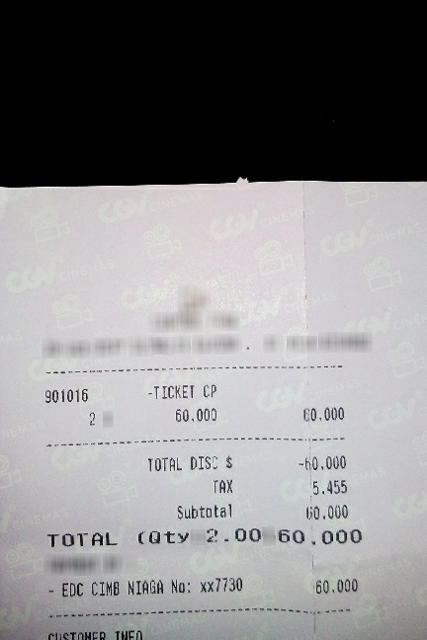

{
  "document_type": "receipt",
  "line_items": [
    {
      "amount": "60.000",
      "name": "-TICKET CP"
    }
  ],
  "subtotal": "60.000",
  "tax": "5.455",
  "total": "60.000"
}


In [4]:
# 4) Load CORD v2 and build datasets

raw_ds = load_dataset(DATASET_ID)

train_ds = convert_split_to_messages(raw_ds["train"], MAX_TRAIN_SAMPLES, keep_target=False)
valid_ds = convert_split_to_messages(raw_ds["validation"], MAX_VALID_SAMPLES, keep_target=False)
test_ds = convert_split_to_messages(raw_ds["test"], MAX_TEST_SAMPLES, keep_target=True)

print(raw_ds)
print(train_ds)
print(valid_ds)
print(test_ds)

sample = test_ds[0]
display(sample["image"])
print(json.dumps(sample["target"], ensure_ascii=False, indent=2))


In [5]:
# 5) Load processor + quantized base model

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

processor = AutoProcessor.from_pretrained(MODEL_ID)

if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token
processor.tokenizer.padding_side = "right"

# Small visual token budget for Kaggle
processor.image_processor.size = {
    "longest_edge": 192 * 32 * 32,
    "shortest_edge": 96 * 32 * 32,
}

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="sdpa",
)

model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

print("Model loaded.")
print("Image processor size:", processor.image_processor.size)


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Model loaded.
Image processor size: {'longest_edge': 196608, 'shortest_edge': 98304}


In [6]:
# 6) LoRA config + Trainer subclass

candidate_targets = []
for t in ["q_proj", "v_proj"]:
    if any(name.endswith(t) for name, _ in model.named_modules()):
        candidate_targets.append(t)

if not candidate_targets:
    candidate_targets = ["q_proj"]

print("LoRA target modules:", candidate_targets)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=candidate_targets,
)


def find_lora_target_modules(model) -> List[str]:
    """
    Finds common linear layers while excluding lm_head and most vision-side layers.
    This is more robust than hardcoding a single architecture-specific list.
    """
    target_modules = set()
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, bnb.nn.Linear4bit, bnb.nn.Linear8bitLt)):
            lname = name.lower()
            if "lm_head" in lname:
                continue
            if "visual" in lname or "vision" in lname or "image" in lname:
                continue
            target_modules.add(name.split(".")[-1])

    # Remove duplicates and common output-only names if present
    blocked = {"lm_head", "output_layer"}
    target_modules = sorted([m for m in target_modules if m not in blocked])
    return target_modules

target_modules = find_lora_target_modules(model)
print("LoRA target modules:", target_modules)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=target_modules,
)

class NoGradNormSFTTrainer(SFTTrainer):
    def _clip_grad_norm(self, model):
        return None

    def _get_grad_norm(self, model, grad_norm=None):
        return None

LoRA target modules: ['q_proj', 'v_proj']
LoRA target modules: ['down_proj', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']


In [7]:
# 7) Train LoRA adapter

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    num_train_epochs=NUM_EPOCHS,
    lr_scheduler_type="cosine",
    logging_steps=5,
    save_strategy="epoch",
    bf16=False,
    fp16=False,
    max_grad_norm=0.0,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    report_to="none",
    remove_unused_columns=False,
    max_length=None,
)

trainer = NoGradNormSFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    processing_class=processor,
    peft_config=lora_config,
)

# Force trainable adapter params to float32
for _, param in trainer.model.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()

trainable_dtypes = Counter(str(p.dtype) for _, p in trainer.model.named_parameters() if p.requires_grad)
print("Trainable dtypes:", trainable_dtypes)
assert "torch.bfloat16" not in trainable_dtypes, f"Found bf16 trainable params: {trainable_dtypes}"

gc.collect()
torch.cuda.empty_cache()

train_result = trainer.train()
print(train_result)

trainer.model.save_pretrained(ADAPTER_DIR)
processor.save_pretrained(ADAPTER_DIR)

print(f"Adapter saved to: {ADAPTER_DIR}")


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Trainable dtypes: Counter({'torch.float32': 504})


Step,Training Loss
5,16.802708
10,15.170212
15,11.987904
20,7.796507
25,6.962862
30,6.520931
35,6.071791
40,5.924814
45,5.589083
50,5.596603


TrainOutput(global_step=64, training_loss=8.081408351659775, metrics={'train_runtime': 378.3415, 'train_samples_per_second': 0.677, 'train_steps_per_second': 0.169, 'total_flos': 2163750738020352.0, 'train_loss': 8.081408351659775})
Adapter saved to: /kaggle/working/qwen3vl_cord_receipt_json/adapter


### Reload for inference

Reloading the adapter onto a fresh base model avoids stale training-state issues and makes the inference path closer to how you will serve the model later.


In [8]:
# 8) Reload fresh base + adapter for inference

del trainer
del model
gc.collect()
torch.cuda.empty_cache()

infer_processor = AutoProcessor.from_pretrained(MODEL_ID)
if infer_processor.tokenizer.pad_token is None:
    infer_processor.tokenizer.pad_token = infer_processor.tokenizer.eos_token
infer_processor.tokenizer.padding_side = "right"
infer_processor.image_processor.size = {
    "longest_edge": 192 * 32 * 32,
    "shortest_edge": 96 * 32 * 32,
}

infer_base = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="sdpa",
)

infer_model = PeftModel.from_pretrained(infer_base, ADAPTER_DIR)
infer_model.eval()

def clean_model_text(text: str) -> str:
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()

def extract_first_json_object(text: str) -> Optional[str]:
    text = clean_model_text(text)
    start = text.find("{")
    if start == -1:
        return None

    depth = 0
    in_string = False
    escape = False

    for i in range(start, len(text)):
        ch = text[i]
        if in_string:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == '"':
                in_string = False
        else:
            if ch == '"':
                in_string = True
            elif ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    return text[start:i+1]
    return None

def parse_model_json(text: str) -> Tuple[Optional[Dict[str, Any]], Optional[str]]:
    candidate = extract_first_json_object(text)
    if candidate is None:
        return None, "No JSON object found in model output."
    try:
        return json.loads(candidate), None
    except Exception as e:
        return None, f"JSON parsing failed: {e}"

def generate_raw_text(model, processor, image: Image.Image, user_prompt: str, max_new_tokens: int = 256) -> str:
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": user_prompt},
            ],
        },
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
    ]
    text = processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    return text

def extract_receipt_json(model, processor, image: Image.Image, max_new_tokens: int = 256):
    raw_text = generate_raw_text(model, processor, image, USER_PROMPT, max_new_tokens=max_new_tokens)
    parsed, error = parse_model_json(raw_text)
    return {
        "raw_text": raw_text,
        "parsed": parsed,
        "error": error,
    }


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


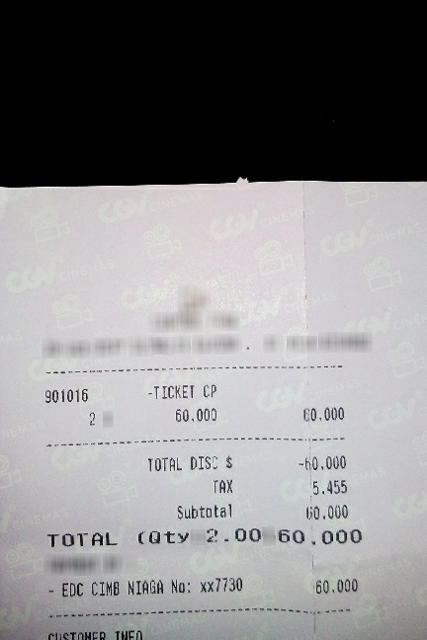

ERROR: None
RAW OUTPUT:
{"document_type":"receipt","line_items":[{"name":"-TICKET CP","amount":"60.000"}],"subtotal":"60.000","tax":"5.455","total":"60.000"}

PARSED JSON:
{
  "document_type": "receipt",
  "line_items": [
    {
      "name": "-TICKET CP",
      "amount": "60.000"
    }
  ],
  "subtotal": "60.000",
  "tax": "5.455",
  "total": "60.000"
}

TARGET:
{
  "document_type": "receipt",
  "line_items": [
    {
      "amount": "60.000",
      "name": "-TICKET CP"
    }
  ],
  "subtotal": "60.000",
  "tax": "5.455",
  "total": "60.000"
}


In [9]:
# 9) Single-sample inference test

pred = extract_receipt_json(infer_model, infer_processor, test_ds[0]["image"], max_new_tokens=256)

display(test_ds[0]["image"])
print("ERROR:", pred["error"])
print("RAW OUTPUT:")
print(pred["raw_text"][:2000])
print("\nPARSED JSON:")
print(json.dumps(pred["parsed"], ensure_ascii=False, indent=2) if pred["parsed"] else None)
print("\nTARGET:")
print(json.dumps(test_ds[0]["target"], ensure_ascii=False, indent=2))


In [10]:
# 10) Evaluation helpers

def money_to_float(x):
    if x is None:
        return None
    s = str(x).strip()
    if s == "":
        return None
    s = re.sub(r"[^0-9.\-]", "", s)
    if s in {"", "-", ".", "-."}:
        return None
    try:
        return float(s)
    except Exception:
        return None

def line_item_sum_amounts(obj: Dict[str, Any]) -> Optional[float]:
    vals = []
    for item in obj.get("line_items", []):
        amt = money_to_float(item.get("amount", ""))
        if amt is not None:
            vals.append(amt)
    if not vals:
        return None
    return round(sum(vals), 2)

def arithmetic_audit(obj: Dict[str, Any]) -> Dict[str, Any]:
    subtotal = money_to_float(obj.get("subtotal", ""))
    tax = money_to_float(obj.get("tax", ""))
    total = money_to_float(obj.get("total", ""))

    issues = []
    details = {}

    li_sum = line_item_sum_amounts(obj)
    details["line_item_sum"] = li_sum

    if subtotal is not None and li_sum is not None and abs(subtotal - li_sum) > 0.01:
        issues.append(f"Subtotal mismatch: subtotal={subtotal}, line_item_sum={li_sum}")

    if subtotal is not None and tax is not None and total is not None:
        expected_total = round(subtotal + tax, 2)
        details["expected_total_from_subtotal"] = expected_total
        if abs(expected_total - total) > 0.01:
            issues.append(f"Total mismatch: expected={expected_total}, found={total}")

    return {
        "is_valid": len(issues) == 0,
        "issues": issues,
        "details": details,
    }

def exact_total_match(pred_obj: Dict[str, Any], true_obj: Dict[str, Any]) -> bool:
    return money_to_float(pred_obj.get("total", "")) == money_to_float(true_obj.get("total", ""))

def exact_subtotal_match(pred_obj: Dict[str, Any], true_obj: Dict[str, Any]) -> bool:
    return money_to_float(pred_obj.get("subtotal", "")) == money_to_float(true_obj.get("subtotal", ""))

def line_item_count_match(pred_obj: Dict[str, Any], true_obj: Dict[str, Any]) -> bool:
    return len(pred_obj.get("line_items", [])) == len(true_obj.get("line_items", []))


In [11]:
# 11) Evaluate on a small held-out subset

def evaluate_on_subset(model, processor, dataset: Dataset, n: int = 10):
    n = min(n, len(dataset))
    parsed_count = 0
    total_match_count = 0
    subtotal_match_count = 0
    line_count_match_count = 0
    arithmetic_valid_count = 0

    rows = []

    for i in range(n):
        ex = dataset[i]
        out = extract_receipt_json(model, processor, ex["image"], max_new_tokens=256)
        pred_obj = out["parsed"]
        true_obj = ex["target"]

        row = {
            "idx": i,
            "parsed_ok": pred_obj is not None,
            "total_match": False,
            "subtotal_match": False,
            "line_item_count_match": False,
            "pred_arithmetic_valid": False,
            "error": out["error"],
        }

        if pred_obj is not None:
            parsed_count += 1
            row["total_match"] = exact_total_match(pred_obj, true_obj)
            row["subtotal_match"] = exact_subtotal_match(pred_obj, true_obj)
            row["line_item_count_match"] = line_item_count_match(pred_obj, true_obj)

            total_match_count += int(row["total_match"])
            subtotal_match_count += int(row["subtotal_match"])
            line_count_match_count += int(row["line_item_count_match"])

            audit = arithmetic_audit(pred_obj)
            row["pred_arithmetic_valid"] = audit["is_valid"]
            arithmetic_valid_count += int(audit["is_valid"])

        rows.append(row)

    metrics = {
        "n_examples": n,
        "json_parse_rate": parsed_count / n,
        "total_exact_match_rate": total_match_count / n,
        "subtotal_exact_match_rate": subtotal_match_count / n,
        "line_item_count_match_rate": line_count_match_count / n,
        "predicted_arithmetic_valid_rate": arithmetic_valid_count / n,
    }

    return metrics, rows

metrics, rows = evaluate_on_subset(infer_model, infer_processor, test_ds, n=min(10, len(test_ds)))
print(json.dumps(metrics, indent=2))
rows[:3]

{
  "n_examples": 10,
  "json_parse_rate": 1.0,
  "total_exact_match_rate": 0.6,
  "subtotal_exact_match_rate": 0.6,
  "line_item_count_match_rate": 0.6,
  "predicted_arithmetic_valid_rate": 0.6
}


[{'idx': 0,
  'parsed_ok': True,
  'total_match': True,
  'subtotal_match': True,
  'line_item_count_match': True,
  'pred_arithmetic_valid': False,
  'error': None},
 {'idx': 1,
  'parsed_ok': True,
  'total_match': False,
  'subtotal_match': False,
  'line_item_count_match': True,
  'pred_arithmetic_valid': True,
  'error': None},
 {'idx': 2,
  'parsed_ok': True,
  'total_match': False,
  'subtotal_match': False,
  'line_item_count_match': False,
  'pred_arithmetic_valid': True,
  'error': None}]

In [12]:
# 12) Agentic audit layer

def schema_check_tool(obj: Optional[Dict[str, Any]]) -> Dict[str, Any]:
    required_top_level = [
        "document_type",
        "line_items",
        "subtotal",
        "tax",
        "total",
    ]
    if obj is None:
        return {"ok": False, "missing": required_top_level, "issues": ["No parsed JSON available."]}

    missing = [k for k in required_top_level if k not in obj]
    issues = []
    if not isinstance(obj.get("line_items", []), list):
        issues.append("line_items is not a list")

    return {
        "ok": len(missing) == 0 and len(issues) == 0,
        "missing": missing,
        "issues": issues,
    }

def missing_critical_fields_tool(obj: Optional[Dict[str, Any]]) -> Dict[str, Any]:
    if obj is None:
        return {"ok": False, "missing_critical": ["total", "line_items"]}

    missing_critical = []

    if money_to_float(obj.get("total", "")) is None:
        missing_critical.append("total")
    if len(obj.get("line_items", [])) == 0:
        missing_critical.append("line_items")

    return {
        "ok": len(missing_critical) == 0,
        "missing_critical": missing_critical,
    }

def business_rule_tool(obj: Optional[Dict[str, Any]]) -> Dict[str, Any]:
    if obj is None:
        return {"ok": False, "issues": ["No parsed object"]}

    issues = []

    total = money_to_float(obj.get("total", ""))
    if total is not None and total <= 0:
        issues.append("Total is non-positive")

    return {
        "ok": len(issues) == 0,
        "issues": issues,
    }

def audit_receipt_image(model, processor, image: Image.Image) -> Dict[str, Any]:
    trace = []

    extraction = extract_receipt_json(model, processor, image)
    trace.append({
        "step": "extract_receipt_json",
        "success": extraction["parsed"] is not None,
        "error": extraction["error"],
    })

    obj = extraction["parsed"]

    schema_result = schema_check_tool(obj)
    trace.append({"step": "schema_check_tool", "result": schema_result})

    arithmetic_result = arithmetic_audit(obj) if obj is not None else {"is_valid": False, "issues": ["No object"], "details": {}}
    trace.append({"step": "arithmetic_audit", "result": arithmetic_result})

    critical_result = missing_critical_fields_tool(obj)
    trace.append({"step": "missing_critical_fields_tool", "result": critical_result})

    policy_result = business_rule_tool(obj)
    trace.append({"step": "business_rule_tool", "result": policy_result})

    issues = []
    if not schema_result["ok"]:
        issues.extend(schema_result["missing"])
        issues.extend(schema_result["issues"])
    if not arithmetic_result["is_valid"]:
        issues.extend(arithmetic_result["issues"])
    if not critical_result["ok"]:
        issues.extend([f"missing critical: {x}" for x in critical_result["missing_critical"]])
    if not policy_result["ok"]:
        issues.extend(policy_result["issues"])

    if obj is None:
        decision = "needs_review"
        rationale = "Model output could not be parsed as valid JSON."
    elif len(critical_result["missing_critical"]) > 0:
        decision = "rejected"
        rationale = "Critical fields are missing."
    elif not arithmetic_result["is_valid"]:
        decision = "needs_review"
        rationale = "Arithmetic or consistency checks failed."
    elif not policy_result["ok"]:
        decision = "needs_review"
        rationale = "Business-rule checks failed."
    else:
        decision = "approved"
        rationale = "Receipt passed extraction, schema, arithmetic, and business-rule checks."

    return {
        "decision": decision,
        "rationale": rationale,
        "issues": issues,
        "extracted_json": obj,
        "raw_model_output": extraction["raw_text"],
        "trace": trace,
    }


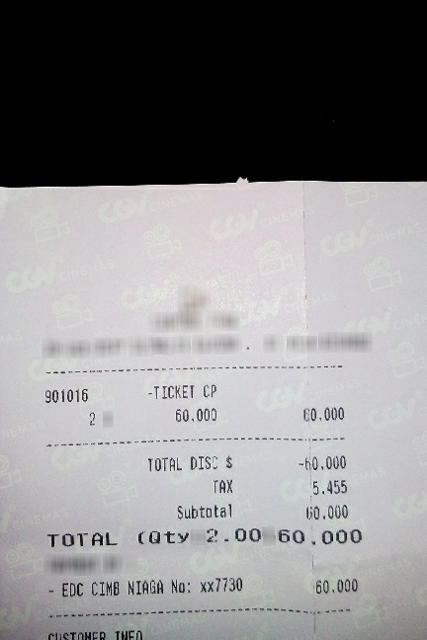

DECISION: needs_review
RATIONALE: Arithmetic or consistency checks failed.

ISSUES:
- Total mismatch: expected=65.45, found=60.0

EXTRACTED JSON:
{
  "document_type": "receipt",
  "line_items": [
    {
      "name": "-TICKET CP",
      "amount": "60.000"
    }
  ],
  "subtotal": "60.000",
  "tax": "5.455",
  "total": "60.000"
}

TRACE:
[
  {
    "step": "extract_receipt_json",
    "success": true,
    "error": null
  },
  {
    "step": "schema_check_tool",
    "result": {
      "ok": true,
      "missing": [],
      "issues": []
    }
  },
  {
    "step": "arithmetic_audit",
    "result": {
      "is_valid": false,
      "issues": [
        "Total mismatch: expected=65.45, found=60.0"
      ],
      "details": {
        "line_item_sum": 60.0,
        "expected_total_from_subtotal": 65.45
      }
    }
  },
  {
    "step": "missing_critical_fields_tool",
    "result": {
      "ok": true,
      "missing_critical": []
    }
  },
  {
    "step": "business_rule_tool",
    "result": {
      

In [13]:
# 13) Run the audit agent on one sample

report = audit_receipt_image(infer_model, infer_processor, test_ds[0]["image"])

display(test_ds[0]["image"])
print("DECISION:", report["decision"])
print("RATIONALE:", report["rationale"])
print("\nISSUES:")
for issue in report["issues"]:
    print("-", issue)

print("\nEXTRACTED JSON:")
print(json.dumps(report["extracted_json"], ensure_ascii=False, indent=2)[:3000])

print("\nTRACE:")
print(json.dumps(report["trace"], ensure_ascii=False, indent=2)[:3000])


In [14]:
# 14) Save artifacts

with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

with open(os.path.join(OUTPUT_DIR, "sample_report.json"), "w") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print("Saved:")
print(os.path.join(OUTPUT_DIR, "metrics.json"))
print(os.path.join(OUTPUT_DIR, "sample_report.json"))
print(ADAPTER_DIR)


Saved:
/kaggle/working/qwen3vl_cord_receipt_json/metrics.json
/kaggle/working/qwen3vl_cord_receipt_json/sample_report.json
/kaggle/working/qwen3vl_cord_receipt_json/adapter


In [15]:
# 15) Zip artifacts for download

!cd /kaggle/working && zip -r qwen3vl_cord_receipt_json_artifacts.zip qwen3vl_cord_receipt_json


  adding: qwen3vl_cord_receipt_json/ (stored 0%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/ (stored 0%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/processor_config.json (deflated 71%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/tokenizer_config.json (deflated 59%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/scheduler.pt (deflated 62%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/README.md (deflated 65%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/optimizer.pt (deflated 9%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/adapter_config.json (deflated 59%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/training_args.bin (deflated 53%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/trainer_state.json (deflated 70%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/adapter_model.safetensors (deflated 8%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/chat_template.jinja (deflated 83%)
  adding: qwen3vl_cord_receipt_json/checkpoint-64/tokeniz